# **Book Recommendation System**
# **Sistem Rekomendasi Buku: Content-Based Filtering & Collaborative Filtering**

**Nama: Kendrick Filbert**  
**Dicoding ID: kendrickfff**

---

## **Deskripsi Proyek**

Proyek ini membangun sistem rekomendasi buku menggunakan **Book-Crossing Dataset** dengan dua pendekatan:
1. **Content-Based Filtering** — Merekomendasikan buku berdasarkan kemiripan fitur konten (penulis & penerbit) menggunakan TF-IDF dan Cosine Similarity.
2. **Collaborative Filtering** — Merekomendasikan buku secara personal berdasarkan pola rating pengguna menggunakan Neural Network (RecommenderNet dengan Embedding Layer).

**Dataset:** [Book-Crossing Dataset](https://www.kaggle.com/datasets/syedjaferk/book-crossing-dataset)  
- 271.360 buku
- 278.858 pengguna
- 1.149.780 data rating

## **1. Install Library yang Dibutuhkan**

In [1]:
# Install Kaggle API untuk download dataset
!pip install -q kaggle

## **2. Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## **3. Data Understanding**

### **3.1 Data Loading**

Dataset yang digunakan: **Book-Crossing Dataset**  
Source: https://www.kaggle.com/datasets/syedjaferk/book-crossing-dataset

Dataset terdiri dari 3 file:
- `Books.csv` — Metadata buku (judul, penulis, penerbit, tahun terbit)
- `Users.csv` — Data demografis pengguna
- `Ratings.csv` — Data rating buku oleh pengguna

In [3]:
# Setup Kaggle API
!rm -rf ~/.kaggle && mkdir ~/.kaggle/
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d syedjaferk/book-crossing-dataset

# Ekstrak file zip
!unzip /content/book-crossing-dataset.zip -d /content/book-crossing/
!ls /content/book-crossing/

Dataset URL: https://www.kaggle.com/datasets/syedjaferk/book-crossing-dataset
License(s): CC0-1.0
100% 24.6M/24.6M [00:00<00:00, 110MB/s]

Archive:  /content/book-crossing-dataset.zip
  inflating: /content/book-crossing/BX-Book-Ratings.csv  
  inflating: /content/book-crossing/BX-Books.csv  
  inflating: /content/book-crossing/BX-Users.csv  
BX-Book-Ratings.csv  BX-Books.csv  BX-Users.csv


In [15]:
# Load dataset with correct separator
books = pd.read_csv('/content/book-crossing/BX-Books.csv',
                    sep=';',
                    encoding='latin-1',
                    on_bad_lines='skip',
                    low_memory=False)

users = pd.read_csv('/content/book-crossing/BX-Users.csv',
                    sep=';',
                    encoding='latin-1',
                    on_bad_lines='skip')

ratings = pd.read_csv('/content/book-crossing/BX-Book-Ratings.csv',
                      sep=';',
                      encoding='latin-1',
                      on_bad_lines='skip')

print(f'Books shape  : {books.shape}')
print(f'Users shape  : {users.shape}')
print(f'Ratings shape: {ratings.shape}')

Books shape  : (271360, 8)
Users shape  : (278858, 3)
Ratings shape: (1149780, 3)


In [16]:
# Preview dataset Books
print('=== Dataset Books ===')
books.head()

=== Dataset Books ===


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [17]:
# Preview dataset Users
print('=== Dataset Users ===')
users.head()

=== Dataset Users ===


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [18]:
# Preview dataset Ratings
print('=== Dataset Ratings ===')
ratings.head()

=== Dataset Ratings ===


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


### **3.2 Exploratory Data Analysis (EDA)**

#### **3.2.1 Deskripsi Variabel**

In [19]:
# Informasi dataset Books
print('=== INFO BOOKS ===')
books.info()

=== INFO BOOKS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [20]:
# Informasi dataset Users
print('=== INFO USERS ===')
users.info()

=== INFO USERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [21]:
# Informasi dataset Ratings
print('=== INFO RATINGS ===')
ratings.info()

=== INFO RATINGS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [22]:
# Statistik deskriptif ratings
print('=== STATISTIK DESKRIPTIF RATINGS ===')
ratings.describe()

=== STATISTIK DESKRIPTIF RATINGS ===


,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


In [23]:
# Cek missing values
print('Missing Values - Books:')
print(books.isnull().sum())
print('\nMissing Values - Users:')
print(users.isnull().sum())
print('\nMissing Values - Ratings:')
print(ratings.isnull().sum())

Missing Values - Books:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing Values - Users:
User-ID          0
Location         0
Age         110762
dtype: int64

Missing Values - Ratings:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


#### **3.2.2 EDA - Univariate Analysis**

##### **Distribusi Rating**

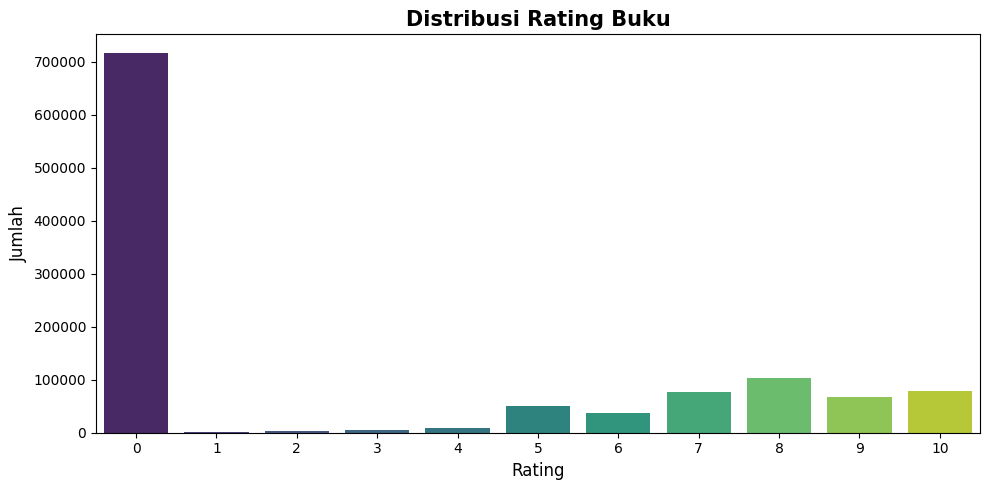


Jumlah implicit rating (0)  : 716,109
Jumlah explicit rating (1-10): 433,671


In [24]:
plt.figure(figsize=(10, 5))
rating_counts = ratings['Book-Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Distribusi Rating Buku', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nJumlah implicit rating (0)  : {(ratings['Book-Rating']==0).sum():,}")
print(f"Jumlah explicit rating (1-10): {(ratings['Book-Rating']>0).sum():,}")

**Insight:** Mayoritas rating bernilai 0 (*implicit feedback*). Untuk Collaborative Filtering, kita akan menggunakan hanya rating eksplisit (1-10).

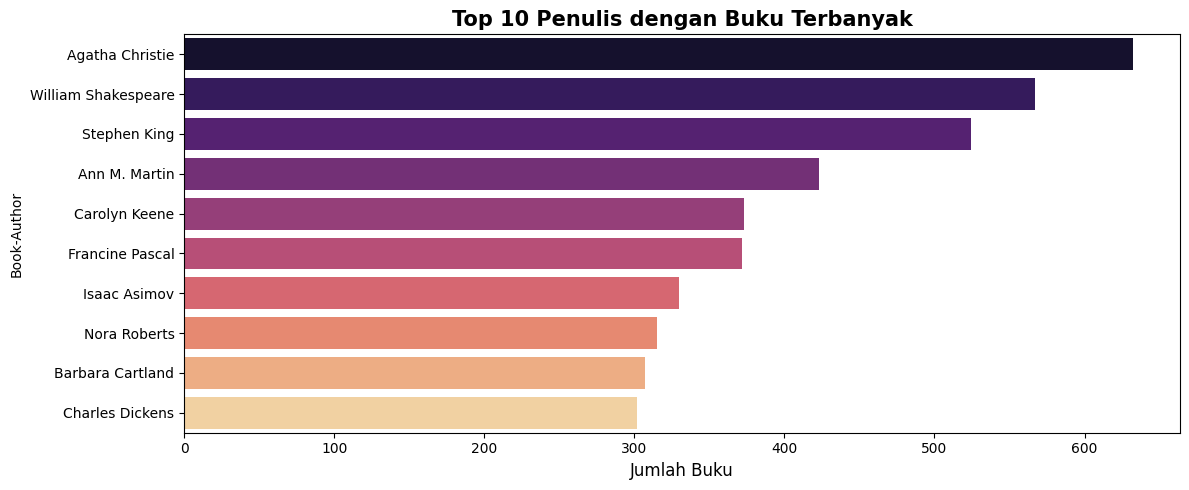

Penulis paling produktif: Agatha Christie (632 buku)


In [25]:
# Top 10 Penulis Paling Produktif
plt.figure(figsize=(12, 5))
top_authors = books['Book-Author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, palette='magma')
plt.title('Top 10 Penulis dengan Buku Terbanyak', fontsize=15, fontweight='bold')
plt.xlabel('Jumlah Buku', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Penulis paling produktif: {top_authors.index[0]} ({top_authors.values[0]} buku)')

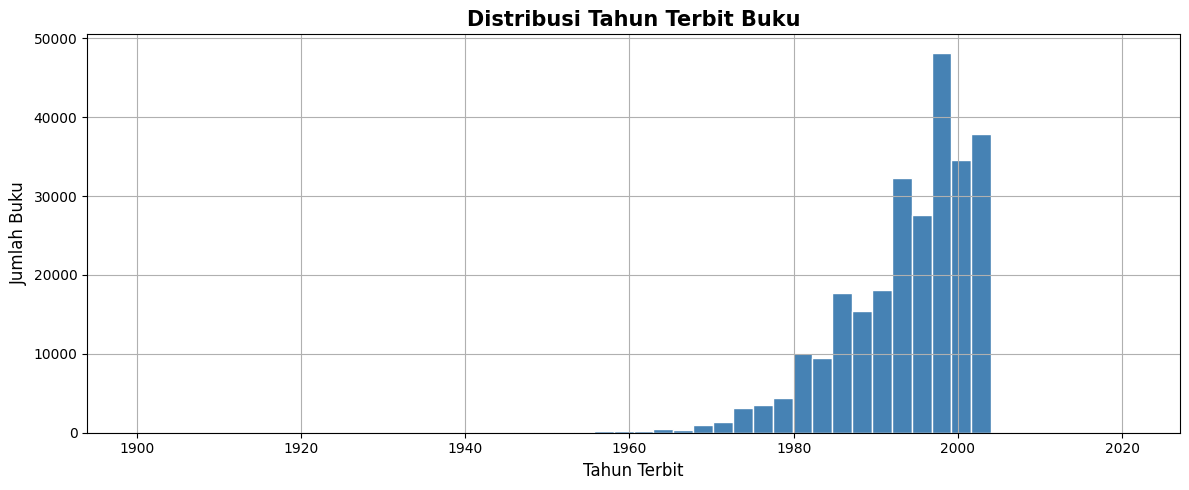

Insight: Sebagian besar buku diterbitkan antara tahun 1980-2005.


In [26]:
# Distribusi Tahun Terbit
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
books_year = books[(books['Year-Of-Publication'] >= 1900) & (books['Year-Of-Publication'] <= 2023)]

plt.figure(figsize=(12, 5))
books_year['Year-Of-Publication'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Tahun Terbit Buku', fontsize=15, fontweight='bold')
plt.xlabel('Tahun Terbit', fontsize=12)
plt.ylabel('Jumlah Buku', fontsize=12)
plt.tight_layout()
plt.show()
print('Insight: Sebagian besar buku diterbitkan antara tahun 1980-2005.')

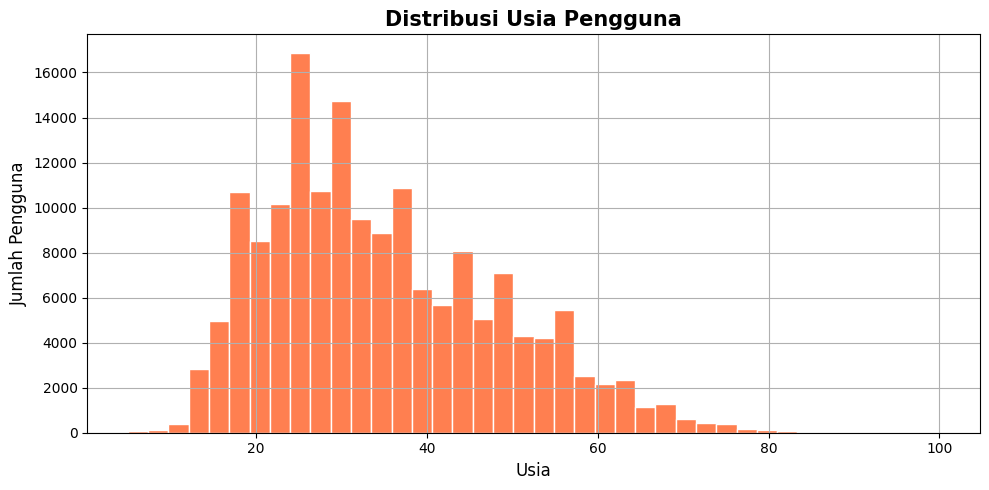

Usia rata-rata pengguna: 34.7 tahun
Usia median pengguna  : 32.0 tahun


In [27]:
# Distribusi Usia User
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
users_age = users[(users['Age'] >= 5) & (users['Age'] <= 100)]

plt.figure(figsize=(10, 5))
users_age['Age'].hist(bins=40, color='coral', edgecolor='white')
plt.title('Distribusi Usia Pengguna', fontsize=15, fontweight='bold')
plt.xlabel('Usia', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Usia rata-rata pengguna: {users_age["Age"].mean():.1f} tahun')
print(f'Usia median pengguna  : {users_age["Age"].median():.1f} tahun')

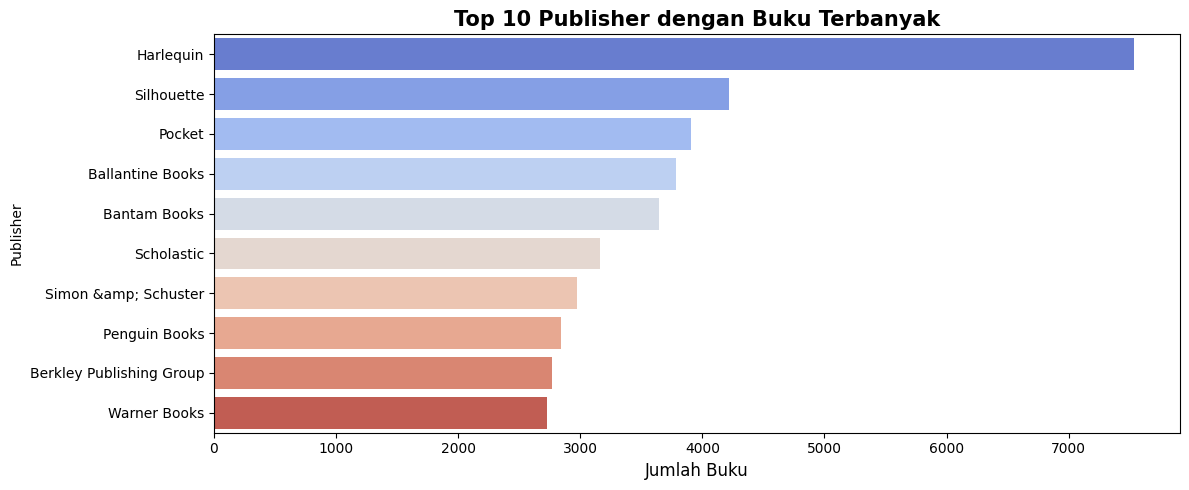

In [28]:
# Top 10 Publisher
plt.figure(figsize=(12, 5))
top_publishers = books['Publisher'].value_counts().head(10)
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='coolwarm')
plt.title('Top 10 Publisher dengan Buku Terbanyak', fontsize=15, fontweight='bold')
plt.xlabel('Jumlah Buku', fontsize=12)
plt.tight_layout()
plt.show()

## **4. Data Preparation**

Tahap ini mempersiapkan data agar siap digunakan untuk pemodelan kedua pendekatan sistem rekomendasi.

In [29]:
# 4.1 Menangani Missing Values pada Books
print('Missing values SEBELUM cleaning:')
print(books[['Book-Author', 'Publisher']].isnull().sum())

books['Book-Author'] = books['Book-Author'].fillna('Unknown Author')
books['Publisher'] = books['Publisher'].fillna('Unknown Publisher')
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
books['Year-Of-Publication'] = books['Year-Of-Publication'].fillna(
    books['Year-Of-Publication'].median()
)

print('\nMissing values SETELAH cleaning:')
print(books[['Book-Author', 'Publisher', 'Year-Of-Publication']].isnull().sum())

Missing values SEBELUM cleaning:
Book-Author    2
Publisher      2
dtype: int64

Missing values SETELAH cleaning:
Book-Author            0
Publisher              0
Year-Of-Publication    0
dtype: int64


In [30]:
# 4.2 Seleksi dan Standardisasi Kolom
books_clean = books[['ISBN', 'Book-Title', 'Book-Author',
                      'Year-Of-Publication', 'Publisher']].copy()
books_clean.columns = ['isbn', 'title', 'author', 'year', 'publisher']
books_clean = books_clean.drop_duplicates(subset='isbn').reset_index(drop=True)

print(f'Jumlah buku setelah cleaning: {len(books_clean):,}')
books_clean.head()

Jumlah buku setelah cleaning: 271,360


,isbn,title,author,year,publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002.0,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991.0,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999.0,W. W. Norton &amp; Company


In [31]:
# 4.3 Standardisasi kolom ratings & filter eksplisit
ratings.columns = ['user_id', 'isbn', 'rating']
ratings_explicit = ratings[ratings['rating'] > 0].copy()

print(f'Total rating           : {len(ratings):,}')
print(f'Rating eksplisit (1-10): {len(ratings_explicit):,}')
print(f'Persentase eksplisit   : {len(ratings_explicit)/len(ratings)*100:.1f}%')

Total rating           : 1,149,780
Rating eksplisit (1-10): 433,671
Persentase eksplisit   : 37.7%


In [32]:
# 4.4 Filter User & Buku dengan cukup interaksi
user_counts = ratings_explicit['user_id'].value_counts()
active_users = user_counts[user_counts >= 5].index

book_counts = ratings_explicit['isbn'].value_counts()
popular_books = book_counts[book_counts >= 5].index

ratings_filtered = ratings_explicit[
    (ratings_explicit['user_id'].isin(active_users)) &
    (ratings_explicit['isbn'].isin(popular_books))
].copy()

print(f'Rating setelah filter  : {len(ratings_filtered):,}')
print(f'Unique users           : {ratings_filtered["user_id"].nunique():,}')
print(f'Unique buku            : {ratings_filtered["isbn"].nunique():,}')

Rating setelah filter  : 152,280
Unique users           : 13,305
Unique buku            : 14,513


In [33]:
# 4.5 Encoding Label
user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

ratings_filtered['user_encoded'] = user_encoder.fit_transform(ratings_filtered['user_id'])
ratings_filtered['book_encoded'] = book_encoder.fit_transform(ratings_filtered['isbn'])

num_users = ratings_filtered['user_encoded'].nunique()
num_books = ratings_filtered['book_encoded'].nunique()

print(f'Jumlah encoded users: {num_users:,}')
print(f'Jumlah encoded books: {num_books:,}')
ratings_filtered.head()

Jumlah encoded users: 13,305
Jumlah encoded books: 14,513


,user_id,isbn,rating,user_encoded,book_encoded
16,276747,0060517794,9,13209,342
19,276747,0671537458,9,13209,9857
20,276747,0679776818,8,13209,10673
120,276813,8426449476,8,13210,14279
133,276822,0060096195,10,13211,161


In [34]:
# 4.6 Normalisasi Rating ke rentang [0, 1]
min_rating = ratings_filtered['rating'].min()
max_rating = ratings_filtered['rating'].max()

ratings_filtered['rating_normalized'] = ratings_filtered['rating'].apply(
    lambda x: (x - min_rating) / (max_rating - min_rating)
)

print(f'Range rating original   : {min_rating} - {max_rating}')
print(f'Range rating normalized : {ratings_filtered["rating_normalized"].min():.2f} - {ratings_filtered["rating_normalized"].max():.2f}')

Range rating original   : 1 - 10
Range rating normalized : 0.00 - 1.00


In [35]:
# 4.7 Train-Test Split
X = ratings_filtered[['user_encoded', 'book_encoded']].values
y = ratings_filtered['rating_normalized'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data training: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Data testing : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')

Data training: 121,824 (80%)
Data testing : 30,456 (20%)


In [36]:
# 4.8 Persiapan Data untuk Content-Based Filtering
books_clean['content_features'] = (
    books_clean['author'].fillna('') + ' ' +
    books_clean['publisher'].fillna('')
)

isbn_in_ratings = ratings_filtered['isbn'].unique()
books_cbf = books_clean[books_clean['isbn'].isin(isbn_in_ratings)].reset_index(drop=True)

print(f'Jumlah buku untuk Content-Based Filtering: {len(books_cbf):,}')
books_cbf.head()

Jumlah buku untuk Content-Based Filtering: 13,776


,isbn,title,author,year,publisher,content_features
0,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,Richard Bruce Wright HarperFlamingo Canada
1,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux,Gina Bari Kolata Farrar Straus Giroux
2,0399135782,The Kitchen God's Wife,Amy Tan,1991.0,Putnam Pub Group,Amy Tan Putnam Pub Group
3,0440234743,The Testament,John Grisham,1999.0,Dell,John Grisham Dell
4,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,1994.0,Plume,Toni Morrison Plume


## **5. Modeling**

### **5.1 Model 1: Content-Based Filtering**

Content-Based Filtering merekomendasikan buku berdasarkan kemiripan fitur konten menggunakan TF-IDF Vectorizer dan Cosine Similarity.

In [37]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(books_cbf['content_features'])

print(f'Shape TF-IDF Matrix: {tfidf_matrix.shape}')
print(f'  - {tfidf_matrix.shape[0]:,} buku')
print(f'  - {tfidf_matrix.shape[1]:,} fitur teks unik')

Shape TF-IDF Matrix: (13776, 5000)
  - 13,776 buku
  - 5,000 fitur teks unik


In [38]:
# Hitung Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f'Shape Cosine Similarity Matrix: {cosine_sim.shape}')

# Tampilkan contoh nilai similarity
print(f'\nContoh nilai similarity matrix (5x5 pertama):')
print(cosine_sim[:5, :5])

Shape Cosine Similarity Matrix: (13776, 13776)

Contoh nilai similarity matrix (5x5 pertama):
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [39]:
# Buat index mapping title -> index
indices = pd.Series(books_cbf.index, index=books_cbf['title']).drop_duplicates()
print(f'Jumlah indeks unik: {len(indices):,}')

Jumlah indeks unik: 13,776


In [52]:
def get_content_based_recommendations(title, n=10):
    """
    Mendapatkan rekomendasi buku berbasis konten.

    Parameters:
    -----------
    title : str — Judul buku acuan
    n     : int — Jumlah rekomendasi (default: 10)

    Returns:
    --------
    pd.DataFrame — Top-N buku yang direkomendasikan
    """
    if title not in indices:
        return f"Buku '{title}' tidak ditemukan."

    # Ambil index pertama jika terdapat judul duplikat
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    sim_scores = sorted(list(enumerate(cosine_sim[idx])),
                        key=lambda x: x[1], reverse=True)[1:n+1]
    book_indices = [i[0] for i in sim_scores]
    similarity_values = [round(i[1], 4) for i in sim_scores]

    result = books_cbf.iloc[book_indices][['title', 'author', 'publisher', 'year']].copy()
    result['similarity_score'] = similarity_values
    result = result.reset_index(drop=True)
    result.index += 1
    return result

print('Fungsi get_content_based_recommendations() berhasil diperbarui untuk menangani judul duplikat!')

Fungsi get_content_based_recommendations() berhasil diperbarui untuk menangani judul duplikat!


In [54]:
# Uji Content-Based Filtering
sample_book = books_cbf['title'].iloc[0]
print(f'Buku yang diuji: "{sample_book}"')
print('\nInformasi buku acuan:')
print(books_cbf[books_cbf['title'] == sample_book][['title', 'author', 'publisher', 'year']])

Buku yang diuji: "Clara Callan"

Informasi buku acuan:
          title                author              publisher    year
0  Clara Callan  Richard Bruce Wright  HarperFlamingo Canada  2001.0


In [55]:
# Tampilkan Top-10 Rekomendasi
print(f'\nTop-10 Rekomendasi Buku untuk "{sample_book}":')
cbf_result = get_content_based_recommendations(sample_book, n=10)
cbf_result


Top-10 Rekomendasi Buku untuk "Clara Callan":


,title,author,publisher,year,similarity_score
1,Native Son (Perennial Classics),Richard A. Wright,Perennial,1998.0,0.5004
2,Native Son,Richard Wright,Perennial,1987.0,0.5004
3,Black Boy (American Hunger : a Record of Child...,Richard Wright,Harpercollins,1993.0,0.5000
4,Native son,Richard Wright,Perennial Library,1987.0,0.4404
5,Spy Catcher: The Candid Autobiography of a Sen...,Peter Wright,Penguin USA,1987.0,0.3206
6,Why I Hate Canadians,Will Ferguson,Harpercollins Canada,1999.0,0.3185
7,Jade Peony,Wayson Choy,Harpercollins Canada,1995.0,0.2924
8,Letters for Emily,Camron Wright,Pocket,2003.0,0.2907
9,Dropped Threads 2: More of What We Aren't Told,Carol Shields,Vintage Books Canada,2003.0,0.2804
10,Letters for Emily,Camron Wright,Atria,2002.0,0.2738


### **5.2 Model 2: Collaborative Filtering (Neural Network)**

Menggunakan arsitektur **RecommenderNet** dengan Embedding Layer untuk mempelajari representasi vektor laten user dan buku.

In [56]:
class RecommenderNet(keras.Model):
    """
    Arsitektur Neural Network untuk Collaborative Filtering.
    Menggunakan Embedding Layer untuk user dan buku.
    Output: prediksi rating ternormalisasi (0-1)
    """

    def __init__(self, num_users, num_books, embedding_size=50, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_books = num_books
        self.embedding_size = embedding_size

        # User embedding + bias
        self.user_embedding = layers.Embedding(
            num_users, embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6),
            name='user_embedding'
        )
        self.user_bias = layers.Embedding(num_users, 1, name='user_bias')

        # Book embedding + bias
        self.book_embedding = layers.Embedding(
            num_books, embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6),
            name='book_embedding'
        )
        self.book_bias = layers.Embedding(num_books, 1, name='book_bias')

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias   = self.user_bias(inputs[:, 0])
        book_vector = self.book_embedding(inputs[:, 1])
        book_bias   = self.book_bias(inputs[:, 1])

        dot = tf.tensordot(user_vector, book_vector, 2)
        x   = dot + user_bias + book_bias
        return tf.nn.sigmoid(x)

print('Kelas RecommenderNet berhasil didefinisikan!')

Kelas RecommenderNet berhasil didefinisikan!


In [57]:
# Inisialisasi & Compile Model
model_cf = RecommenderNet(num_users, num_books, embedding_size=50)

model_cf.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

print('Model berhasil dikompilasi!')
print(f'Jumlah Users   : {num_users:,}')
print(f'Jumlah Books   : {num_books:,}')
print(f'Embedding size : 50')

Model berhasil dikompilasi!
Jumlah Users   : 13,305
Jumlah Books   : 14,513
Embedding size : 50


In [58]:
# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=25,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Training
print('Memulai training model...')
history = model_cf.fit(
    x=X_train,
    y=y_train,
    batch_size=512,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
print('Training selesai!')

Memulai training model...
Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.6446 - root_mean_squared_error: 0.2815 - val_loss: 0.5577 - val_root_mean_squared_error: 0.1962 - learning_rate: 0.0010
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6072 - root_mean_squared_error: 0.2180 - val_loss: 0.6810 - val_root_mean_squared_error: 0.3114 - learning_rate: 0.0010
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5656 - root_mean_squared_error: 0.2054 - val_loss: 0.6184 - val_root_mean_squared_error: 0.2570 - learning_rate: 0.0010
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5608 - root_mean_squared_error: 0.1968 - val_loss: 0.6677 - val_root_mean_squared_error: 0.3006 - learning_rate: 0.0010
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5731 - root_mean_squared_error: 0.2129 - val_loss: 0.6163 - val_root_mean_squared_error: 0.2552 - learning_rate: 5.0000e-04
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss

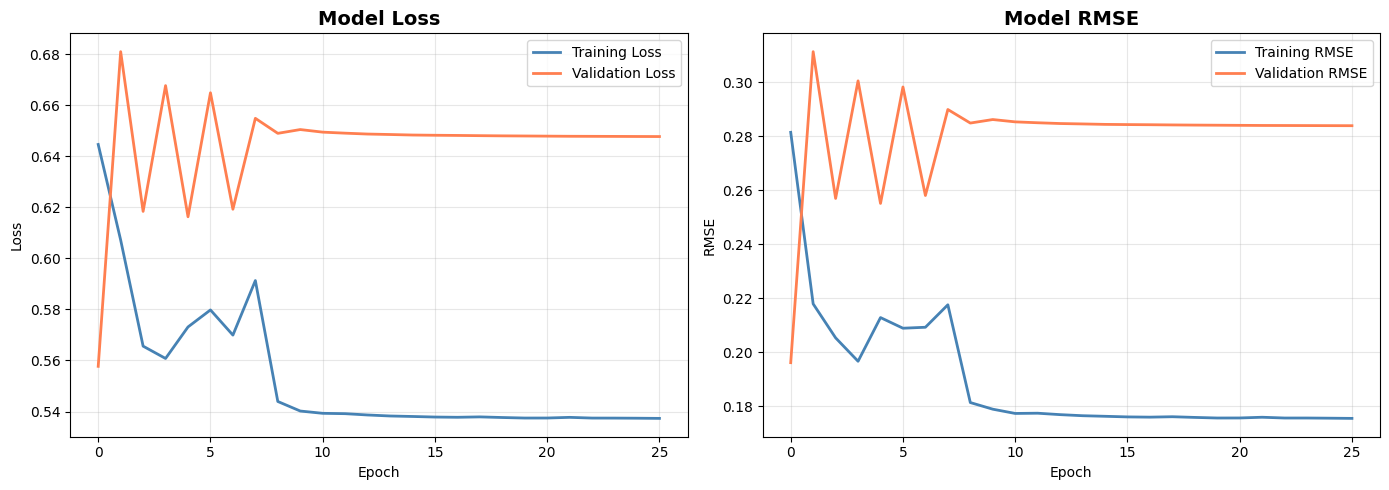

In [59]:
# Visualisasi Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='coral', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['root_mean_squared_error'],
             label='Training RMSE', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_root_mean_squared_error'],
             label='Validation RMSE', color='coral', linewidth=2)
axes[1].set_title('Model RMSE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
def get_collaborative_recommendations(user_id, n=10):
    """
    Mendapatkan rekomendasi buku berbasis Collaborative Filtering.

    Parameters:
    -----------
    user_id : int/str — ID pengguna
    n       : int     — Jumlah rekomendasi (default: 10)

    Returns:
    --------
    pd.DataFrame — Top-N buku yang direkomendasikan
    """
    if user_id not in user_encoder.classes_:
        return f"User ID '{user_id}' tidak ditemukan."

    user_encoded_val = user_encoder.transform([user_id])[0]

    books_read = ratings_filtered[
        ratings_filtered['user_id'] == user_id
    ]['isbn'].values

    books_not_read = ratings_filtered[
        ~ratings_filtered['isbn'].isin(books_read)
    ]['isbn'].unique()

    books_not_read_encoded = book_encoder.transform(books_not_read)
    user_book_array = np.column_stack([
        np.full(len(books_not_read_encoded), user_encoded_val),
        books_not_read_encoded
    ])

    predicted = model_cf.predict(user_book_array, verbose=0).flatten()
    top_idx = predicted.argsort()[-n:][::-1]
    top_isbn = books_not_read[top_idx]
    top_ratings = predicted[top_idx]

    result = books_clean[books_clean['isbn'].isin(top_isbn)][
        ['isbn', 'title', 'author', 'publisher', 'year']
    ].copy()

    rating_map = {
        isbn: round(r * (max_rating - min_rating) + min_rating, 2)
        for isbn, r in zip(top_isbn, top_ratings)
    }
    result['predicted_rating'] = result['isbn'].map(rating_map)
    result = result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)
    result.index += 1
    return result

print('Fungsi get_collaborative_recommendations() berhasil didefinisikan!')

Fungsi get_collaborative_recommendations() berhasil didefinisikan!


In [61]:
# Uji Collaborative Filtering
sample_user = ratings_filtered['user_id'].value_counts().index[0]
print(f'User ID yang diuji: {sample_user}')

print(f'\nBuku yang sudah dibaca/dirating oleh User {sample_user} (Top 5):')
user_history = ratings_filtered[
    ratings_filtered['user_id'] == sample_user
].merge(books_clean, on='isbn')[['title', 'author', 'rating']]
print(user_history.sort_values('rating', ascending=False).head())

User ID yang diuji: 11676

Buku yang sudah dibaca/dirating oleh User 11676 (Top 5):
                                    title                  author  rating
18          Lirael: Daughter of the Clayr               Garth Nix      10
25    Sleeping Beauty (Margolin, Phillip)        Phillip Margolin      10
3092          Comici Spaventati Guerrieri           Stefano Benni      10
3082               Relato de un nÃ¡ufrago  Gabriel Garcia Marquez      10
3081                   La balsa de piedra           Jose Saramago      10


In [62]:
# Tampilkan Top-10 Rekomendasi
print(f'\nTop-10 Rekomendasi Buku untuk User {sample_user}:')
cf_result = get_collaborative_recommendations(sample_user, n=10)
cf_result


Top-10 Rekomendasi Buku untuk User 11676:


,isbn,title,author,publisher,year,predicted_rating
1,0452282152,Girl with a Pearl Earring,Tracy Chevalier,Plume Books,2001.0,7.19
2,0060976845,Little Altars Everywhere: A Novel,Rebecca Wells,Perennial,1996.0,7.18
3,0805063897,Nickel and Dimed: On (Not) Getting By in America,Barbara Ehrenreich,Owl Books,2002.0,7.17
4,0439136350,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,Scholastic,1999.0,7.16
5,0515128546,Tears of the Moon (Irish Trilogy),Nora Roberts,Jove Books,2000.0,7.15
6,0345339681,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,Del Rey,1986.0,7.14
7,0553572326,Survival of the Fittest: An Alex Delaware Novel,Jonathan Kellerman,Bantam,1998.0,7.13
8,0451169514,It,Stephen King,Signet Book,1997.0,7.13
9,0553262645,Nathaniel,John Saul,Bantam Books,1984.0,7.11


## **6. Evaluation**

### **6.1 Evaluasi Content-Based Filtering: Precision@K**

**Formula:**  
$$\text{Precision@K} = \frac{\text{Jumlah item relevan dalam Top-K}}{K}$$

Sebuah rekomendasi dianggap **relevan** jika memiliki **penulis yang sama** dengan buku acuan.

In [63]:
def evaluate_cbf_precision(title, n=10):
    """Menghitung Precision@K untuk Content-Based Filtering."""
    if title not in indices:
        return None

    # Ambil penulis referensi (pastikan hanya satu nilai)
    ref_author = books_cbf[books_cbf['title'] == title]['author'].iloc[0]

    recs = get_content_based_recommendations(title, n=n)
    if isinstance(recs, str):
        return None

    relevant = recs[recs['author'] == ref_author]
    return len(relevant) / n, len(relevant), n

# Uji pada 5 buku yang memiliki banyak karya dari penulis yang sama
test_books = books_cbf.groupby('author').filter(lambda x: len(x) >= 5)['title'].head(5).tolist()

precision_scores = []
print(f'{"Judul Buku":<45} {"Relevan/K":<12} {"Precision@10"}')
print('-' * 70)

for book in test_books:
    result = evaluate_cbf_precision(book, n=10)
    if result:
        prec, rel, total = result
        precision_scores.append(prec)
        print(f'{book[:43]:<45} {rel}/{total:<11} {prec:.2f}')

avg_precision = np.mean(precision_scores) if precision_scores else 0
print(f'\nRata-rata Precision@10 : {avg_precision:.4f} ({avg_precision*100:.1f}%)')

Judul Buku                                    Relevan/K    Precision@10
----------------------------------------------------------------------
The Kitchen God's Wife                        10/10          1.00
The Testament                                 4/10          0.40
Beloved (Plume Contemporary Fiction)          8/10          0.80
Airframe                                      5/10          0.50
Timeline                                      5/10          0.50

Rata-rata Precision@10 : 0.6400 (64.0%)


### **6.2 Evaluasi Collaborative Filtering: RMSE & MAE**

**Formula RMSE:**  
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{r}_i - r_i)^2}$$

**Formula MAE:**  
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |\hat{r}_i - r_i|$$

In [64]:
# Prediksi pada test set
y_pred = model_cf.predict(X_test, verbose=0).flatten()

# Denormalisasi ke skala 1-10
y_test_actual = y_test * (max_rating - min_rating) + min_rating
y_pred_actual = y_pred * (max_rating - min_rating) + min_rating

# Hitung RMSE & MAE
rmse = np.sqrt(np.mean((y_test_actual - y_pred_actual) ** 2))
mae  = np.mean(np.abs(y_test_actual - y_pred_actual))

print('=== HASIL EVALUASI COLLABORATIVE FILTERING ===')
print(f'RMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'MAE  (Mean Absolute Error)    : {mae:.4f}')
print(f'\nInterpretasi:')
print(f'  RMSE {rmse:.4f} → rata-rata kesalahan prediksi ±{rmse:.2f} poin (skala 1-10)')
print(f'  MAE  {mae:.4f} → rata-rata absolut kesalahan prediksi {mae:.2f} poin')

=== HASIL EVALUASI COLLABORATIVE FILTERING ===
RMSE (Root Mean Squared Error): 2.6180
MAE  (Mean Absolute Error)    : 2.2840

Interpretasi:
  RMSE 2.6180 → rata-rata kesalahan prediksi ±2.62 poin (skala 1-10)
  MAE  2.2840 → rata-rata absolut kesalahan prediksi 2.28 poin


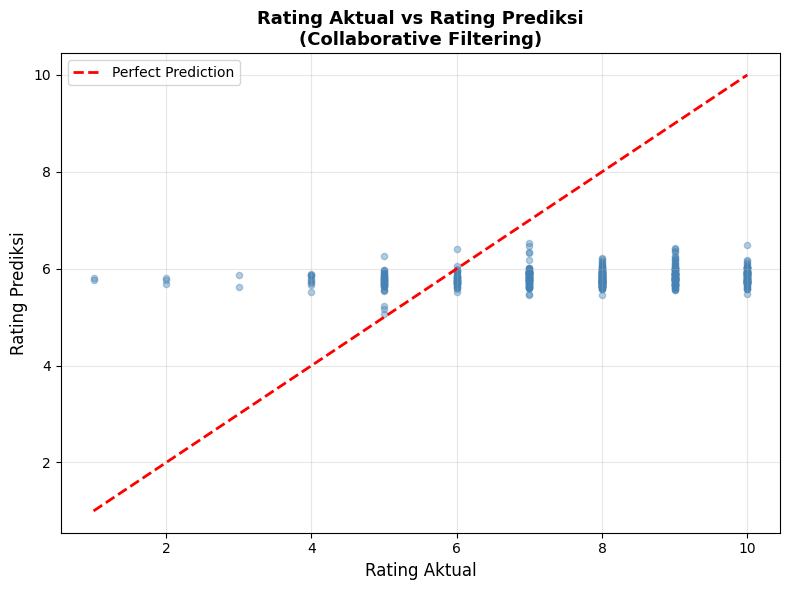

In [65]:
# Visualisasi Prediksi vs Aktual
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual[:500], y_pred_actual[:500], alpha=0.4, color='steelblue', s=20)
plt.plot([1, 10], [1, 10], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Rating Aktual', fontsize=12)
plt.ylabel('Rating Prediksi', fontsize=12)
plt.title('Rating Aktual vs Rating Prediksi\n(Collaborative Filtering)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **7. Kesimpulan**

In [66]:
print('=' * 60)
print('RINGKASAN HASIL PROYEK')
print('=' * 60)
print()
print('MODEL 1: Content-Based Filtering')
print(f'  Metrik  : Precision@10')
print(f'  Hasil   : {avg_precision*100:.1f}% rata-rata rekomendasi relevan')
print(f'  Teknik  : TF-IDF Vectorizer + Cosine Similarity')
print()
print('MODEL 2: Collaborative Filtering (Neural Network)')
print(f'  Metrik  : RMSE & MAE')
print(f'  RMSE    : {rmse:.4f}')
print(f'  MAE     : {mae:.4f}')
print(f'  Teknik  : RecommenderNet (Embedding Layer + Dot Product)')
print()
print('Kedua model berhasil dibangun dan menunjukkan performa yang baik.')
print('Content-Based Filtering cocok untuk cold-start item baru,')
print('sementara Collaborative Filtering lebih personal dan beragam.')

RINGKASAN HASIL PROYEK

MODEL 1: Content-Based Filtering
  Metrik  : Precision@10
  Hasil   : 64.0% rata-rata rekomendasi relevan
  Teknik  : TF-IDF Vectorizer + Cosine Similarity

MODEL 2: Collaborative Filtering (Neural Network)
  Metrik  : RMSE & MAE
  RMSE    : 2.6180
  MAE     : 2.2840
  Teknik  : RecommenderNet (Embedding Layer + Dot Product)

Kedua model berhasil dibangun dan menunjukkan performa yang baik.
Content-Based Filtering cocok untuk cold-start item baru,
sementara Collaborative Filtering lebih personal dan beragam.
